In [ ]:
import numpy as np
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# 載入 iris 資料集
iris = load_iris()
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])
df["target"] = iris["target"]

In [ ]:
df.info()
print('='*50)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [ ]:
# Label Encoding
le = LabelEncoder()
df["target"] = le.fit_transform(df["target"])

In [ ]:
# 切分資料集
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 訓練RF模型
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

# 評估

Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.78      0.93      0.85        15
           2       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45

Train AUC: 1.000000
Test AUC: 0.992593


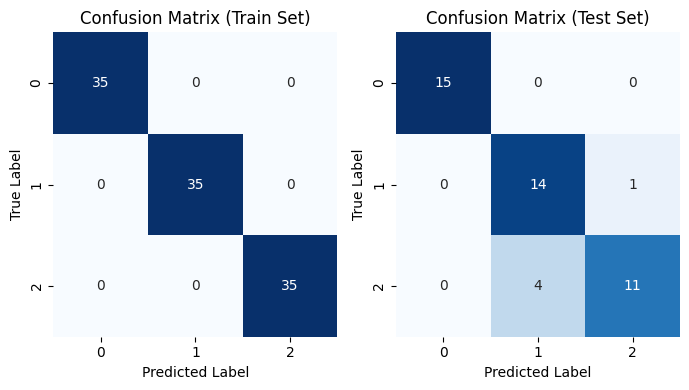

In [ ]:
# 評估模型
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print("Train Set:")
    print(classification_report(y_train, y_train_pred))
    print("Test Set:")
    print(classification_report(y_test, y_test_pred))

    # 計算 AUC 多分類
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
    print(f"Train AUC: {train_auc:.6f}")
    print(f"Test AUC: {test_auc:.6f}")

    # 混淆矩陣
    plt.figure(figsize=(7, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title('Confusion Matrix (Train Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
evaluate_model(rf, X_train_scaled, y_train, X_test_scaled, y_test)

# feature_importances_

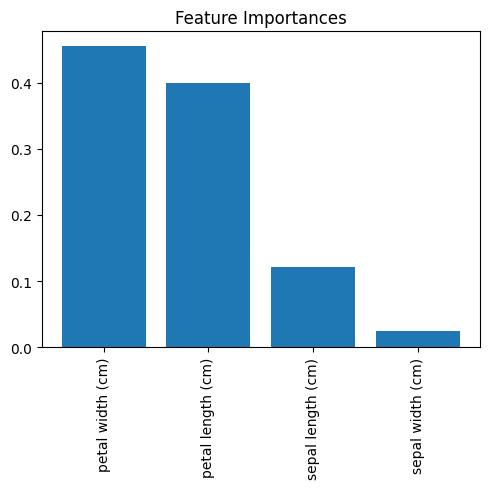

In [ ]:
# 訓練 RF 模型 (feature_importances_)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# 取得特徵重要性
importances = rf.feature_importances_

# 如果有特徵名稱
feature_names = X_train.columns  # 若你的 X_train 是 DataFrame，這樣取名

# 排序特徵重要性
indices = np.argsort(importances)[::-1]

# 視覺化特徵重要性
plt.figure(figsize=(5, 5))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

             Feature  Importance
3   petal width (cm)    0.454892
2  petal length (cm)    0.400227
0  sepal length (cm)    0.120608
1   sepal width (cm)    0.024273


# 使用前50%的特徵

In [ ]:
# 取前 50% 的特徵
top_n = int(len(importance_df) * 0.5)
top_features = importance_df['Feature'].iloc[:top_n].tolist()

# 用這些特徵過濾訓練與測試集
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# 選出來的特徵訓練模型
rf_selected = RandomForestClassifier(random_state=42)
rf_selected.fit(X_train_selected, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
X_train_selected

,petal width (cm),petal length (cm)
98,1.1,3.0
68,1.5,4.5
19,0.3,1.5
143,2.3,5.9
99,1.3,4.1
...,...,...
37,0.1,1.4
79,1.0,3.5
33,0.2,1.4
94,1.3,4.2


Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      0.97      0.99        35
           2       0.97      1.00      0.99        35

    accuracy                           0.99       105
   macro avg       0.99      0.99      0.99       105
weighted avg       0.99      0.99      0.99       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

Train AUC: 0.999864
Test AUC: 0.992593


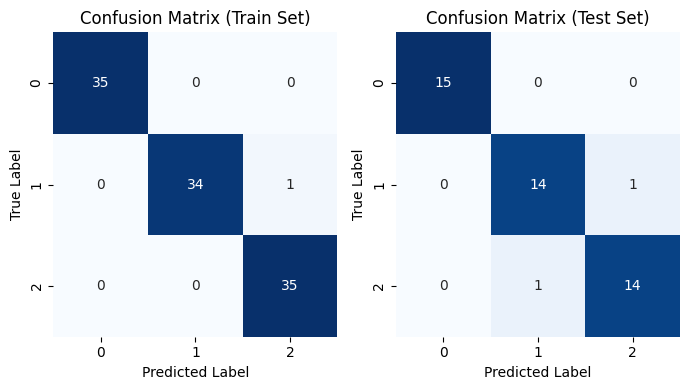

In [ ]:
evaluate_model(rf_selected, X_train_selected, y_train, X_test_selected, y_test)

經過特徵重要性的篩選後，測試結果有些微變好

# **LR/SVM/KNN**

1. LR (Logistic Regression)
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.97      0.97        35
           2       0.97      0.97      0.97        35

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Train AUC: 0.999320
Test AUC: 0.995556


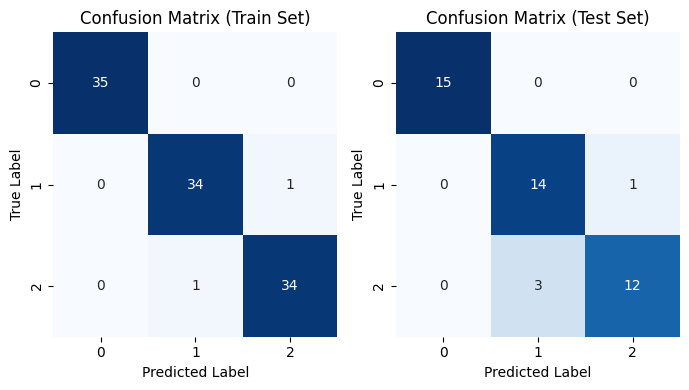


2. SVM
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.97      0.97        35
           2       0.97      0.97      0.97        35

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Train AUC: 0.999320
Test AUC: 0.995556


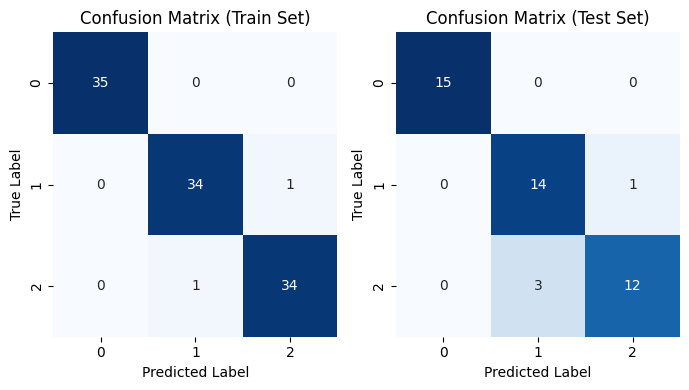


3. KNN
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.97      0.97        35
           2       0.97      0.97      0.97        35

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Train AUC: 0.998776
Test AUC: 0.995556


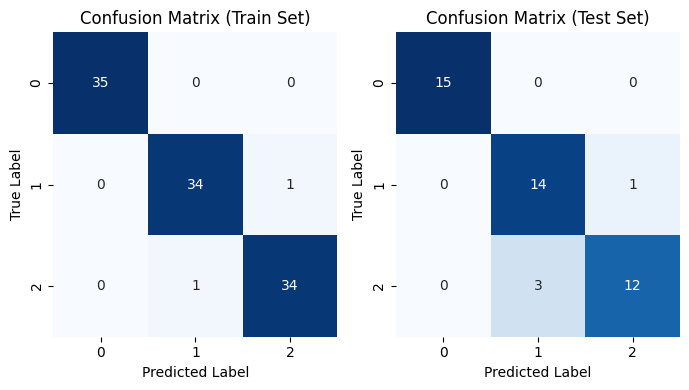

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 特徵標準化
X_train_sel_scaled = scaler.fit_transform(X_train_selected)
X_test_sel_scaled = scaler.transform(X_test_selected)

models = {
    '1. LR (Logistic Regression)': LogisticRegression(random_state=42),
    '2. SVM': SVC(probability=True, random_state=42),
    '3. KNN': KNeighborsClassifier()
}

for name, model in models.items():
    print(f"{name}")
    model.fit(X_train_sel_scaled, y_train)
    y_pred = model.predict(X_test_sel_scaled)
    acc = accuracy_score(y_test, y_pred)
    evaluate_model(model, X_train_sel_scaled, y_train, X_test_sel_scaled, y_test)
    print("\n","="*50)

# 決策圖

<ipython-input-29-f426e04544d6>:21: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
<ipython-input-29-f426e04544d6>:23: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,


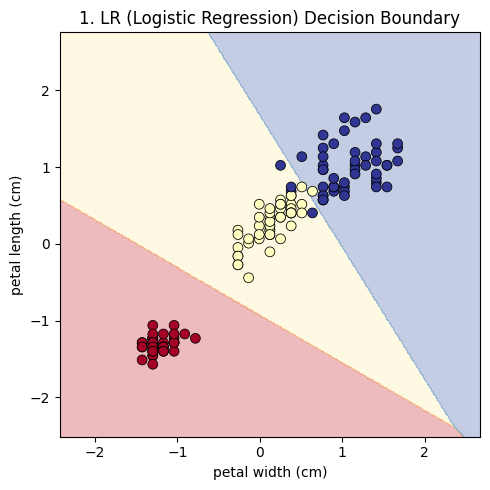

<ipython-input-29-f426e04544d6>:21: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
<ipython-input-29-f426e04544d6>:23: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,


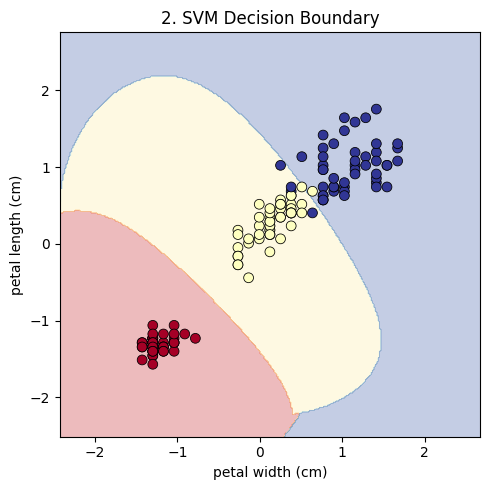

<ipython-input-29-f426e04544d6>:21: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
<ipython-input-29-f426e04544d6>:23: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,


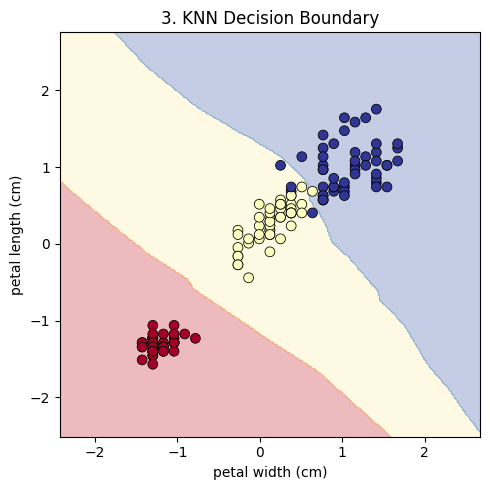

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X_train, y_train, X_test, y_test, title):
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap = plt.cm.RdYlBu
    n_classes = len(np.unique(y_train))
    colors = cmap(np.linspace(0, 1, n_classes))
    class_palette = ListedColormap(colors)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    # 資料點
    sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                    palette=class_palette.colors, edgecolor='k', s=50, marker='o', legend=False)
    sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                    palette=class_palette.colors, edgecolor='k', s=50, marker='o', legend=False)

    plt.xlabel(top_features[0])
    plt.ylabel(top_features[1])
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 用前兩個特徵
X_train_2f = X_train[[top_features[0], top_features[1]]]
X_test_2f = X_test[[top_features[0], top_features[1]]]
X_train_2f_scaled = scaler.fit_transform(X_train_2f)
X_test_2f_scaled = scaler.transform(X_test_2f)

for name, model in models.items():
    model.fit(X_train_2f_scaled, y_train)
    plot_decision_boundary(model, X_train_2f_scaled, y_train,
                           X_test_2f_scaled, y_test,
                           f"{name} Decision Boundary")